In [1]:
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUseRejectionSampling, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel,EQIntegralKernel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from jax.random import normal
import jax
from jax.random import multivariate_normal as mvn
from scipy.stats import circmean
import pickle
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Load the file we want to infer a path from,

In [2]:
pathIndex = 2
nSamps = 25 # Max number of samples to use per burst for path reconstruction
             # (2 second bursts, how many samples within that burst)
paths = [["../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/complexpath7.log", "../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/2025-03-26_12_05_30_my_iOS_device.csv", 8,26],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/complexpath8.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/2025-03-26_12_09_13_my_iOS_device.csv",7,24],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv" ,5,28]]

In [3]:
testdata = Signals(paths[pathIndex][0],['c','a','b','e'],filetype='log',angleOffset=0)
GPSfilepath = paths[pathIndex][1]

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = paths[pathIndex][2]
endingTime = paths[pathIndex][3]

Standardising angles and times (shifting by 0.00 degrees)


Define hyperparameters (keep the same across all tests):

In [4]:
nInd = 60 # Number of inducing points
noise = 1 # Noise scale
timeScale = 10000 # Scale time series down by this factor when preparing observations
margin = 0.3 # Percentage of time that inducing points will be selected between outside the actual time series of the data

burstLength = 2000 # in ms
samplingMethod = "linspaceIdxs" # random, linspaceTimes, linspaceIdxs

# k(ls,sf)
#k = ExponentiatedQuadraticKernel(3,13)
#k = EQIntegralKernel(2,5)
k = EQIntegralKernel(0.5,0.5)

Define the transmitter IDs, locations and times,

Transmitter       Number of records
        a                 8467
        b                 3744
        c                14636
        e                 7515


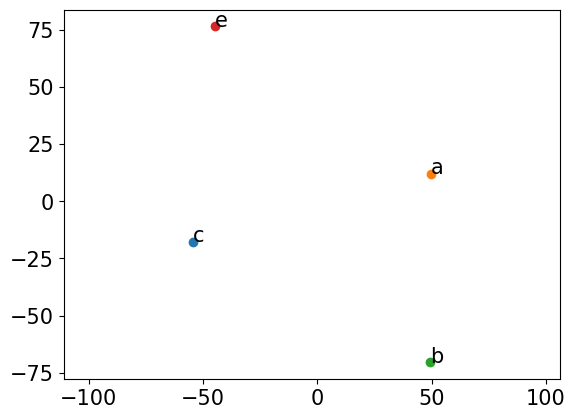

In [5]:
testdata.configureTransmitter('c',0,np.deg2rad(15),transmitterLat = 53.368359, transmitterLon = -1.450168)
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
testdata.configureTransmitter('b',-(167340+194210+121110),-np.deg2rad(15),transmitterLat = 53.367865, transmitterLon = -1.448626)
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()
testdata.summarise(showNormalised = True)

# Using peak signal strength heuristic

Prepare observations,

In [326]:
obs = []
obstimes = []

# Get packet bursts from data
burst, time = testdata.parseBursts(burstInterval=0)
angles = AnglesUsePeaks(windowLength=3)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    print(burst[b])
    prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
    # If a peak was found
    if not (np.isnan(prediction)):
        # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
        obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
        # Add time of observation
        obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

{'transmitter_position': array([[-17.81935723, -54.39385984]]), 'rssis': array([-95., -95., -95., -96., -96., -95., -92., -91., -97., -91., -95.,
       -87., -84., -88., -80., -83., -82., -79., -80., -81., -82., -85.,
       -89., -94., -94.]), 'angles': array([ 1.29154365,  1.32645023,  3.17649924,  4.81710874,  4.86946861,
        5.11381471,  5.27089434,  5.27089434,  5.32325422,  5.41052068,
        5.46288056,  5.65486678,  5.70722665,  5.75958653,  5.81194641,
        5.89921287,  5.95157275, -0.17453293, -0.03490659, -0.03490659,
        0.01745329,  0.12217305,  0.17453293,  0.2268928 ,  1.88495559]), 'times': array([   0.,   13.,  543., 1018., 1033., 1104., 1147., 1147., 1163.,
       1191., 1206., 1262., 1277., 1292., 1305., 1336., 1348., 1392.,
       1435., 1435., 1450., 1478., 1494., 1509., 1993.])}
{'transmitter_position': array([[-17.81935723, -54.39385984]]), 'rssis': array([-96., -98., -95., -94., -94., -96., -93., -96., -96., -92., -96.,
       -93., -89., -90., -86.

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


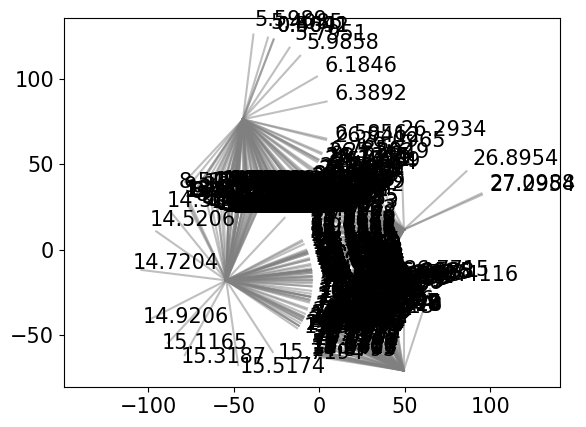

In [327]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

Perform inference,

In [328]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 1)
path.run(250,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0:  310100.4
iteration   50:   94228.0
iteration  100:   76126.6
iteration  150:   73104.7
iteration  200:   72160.6
Optimising mean and covariance...
iteration    0:   53004.0
iteration   50:   44765.7
iteration  100:   35683.8
iteration  150:   33962.3
iteration  200:   33799.9


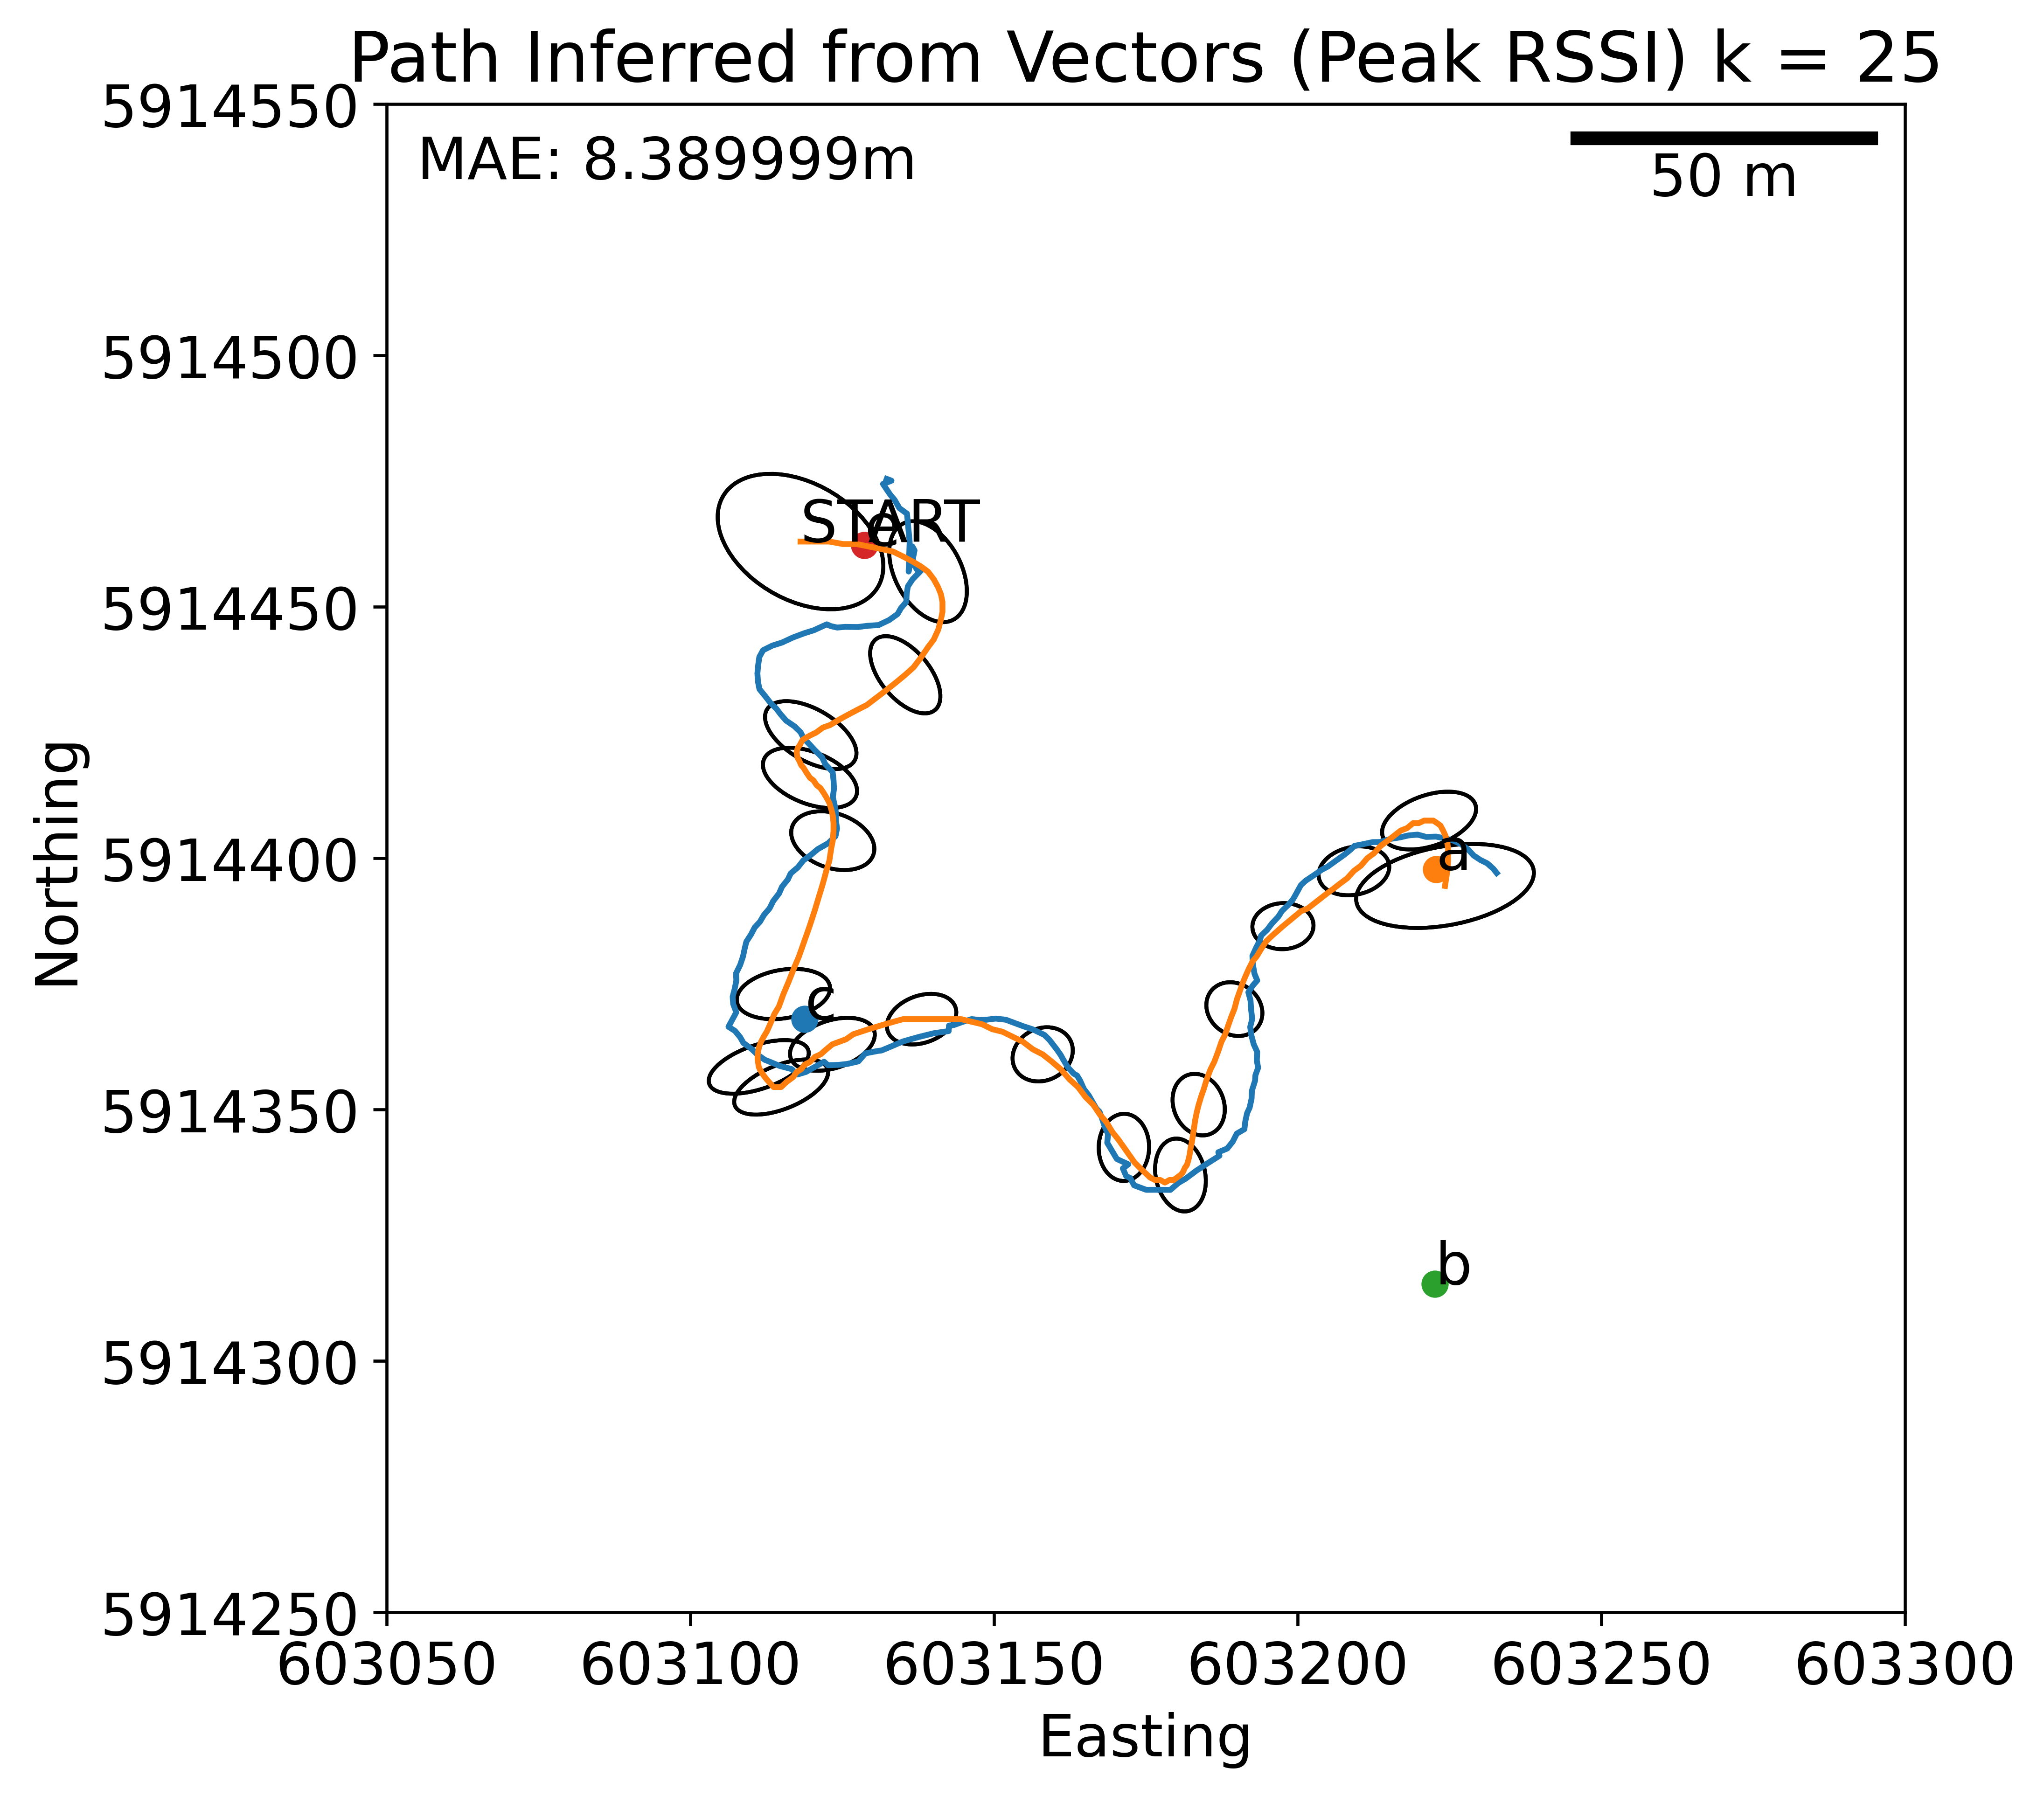

In [329]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 20, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath, n_std = 3)

plt.title("Path Inferred from Vectors (Peak RSSI) k = " + str(nSamps))
plt.xlim(603050,603300)
plt.ylim(5914250,5914550)
ax1.legend_ = None

plt.savefig("path2.png", bbox_inches='tight')

# Using rejection sampling (not used in paper)

Standardising angles and times (shifting by 38.00 degrees)
Burst 0 out of 420
Burst 10 out of 420
Burst 20 out of 420
Burst 30 out of 420
Burst 40 out of 420
Burst 50 out of 420
Burst 60 out of 420
Burst 70 out of 420
Burst 80 out of 420
Burst 90 out of 420
Burst 100 out of 420
Burst 110 out of 420
Burst 120 out of 420
Burst 130 out of 420
Burst 140 out of 420
Burst 150 out of 420
Burst 160 out of 420
Burst 170 out of 420
Burst 180 out of 420
Burst 190 out of 420
Burst 200 out of 420
Burst 210 out of 420
Burst 220 out of 420
Burst 230 out of 420
Burst 240 out of 420
Burst 250 out of 420
Burst 260 out of 420
Burst 270 out of 420
Burst 280 out of 420
Burst 290 out of 420
Burst 300 out of 420
Burst 310 out of 420
Burst 320 out of 420
Burst 330 out of 420
Burst 340 out of 420
Burst 350 out of 420
Burst 360 out of 420
Burst 370 out of 420
Burst 380 out of 420
Burst 390 out of 420
Burst 400 out of 420
Burst 410 out of 420


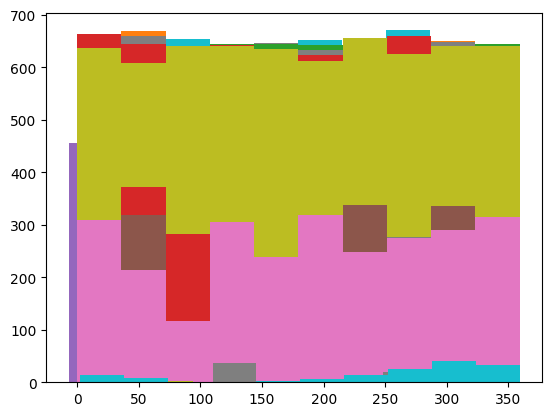

In [41]:
rejectionSamp = AnglesUseRejectionSampling(rejectionTableStep = 100)

obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    prediction = rejectionSamp.infer(burst[b], rejectionThreshold = 4) 
    if not (np.isnan(prediction)):
        #print(burst[b]["times"])
        # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
        obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
        # Add time of observation
        obstimes.append(time[b])
    if b % 10 == 0:
        print("Burst " + str(b) + " out of " + str(len(burst)))

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

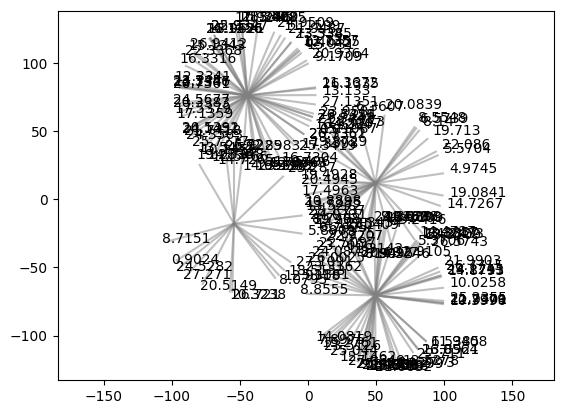

In [42]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [22]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 1)
path.run(500,learning_rate=0.5, just_optimise_means = False)

Optimising mean...
iteration    0:  295779.1
iteration   50:  261640.9
iteration  100:  255977.5
iteration  150:  254446.8
iteration  200:  254031.8
iteration  250:  253799.2
iteration  300:  253753.5
iteration  350:  253637.1
iteration  400:  253794.3
iteration  450:  253881.8
Optimising mean and covariance...
iteration    0:  250391.5
iteration   50:  240856.4
iteration  100:  236367.0
iteration  150:  232883.2
iteration  200:  230036.3
iteration  250:  228312.5
iteration  300:  226770.7
iteration  350:  225453.2
iteration  400:  224129.4
iteration  450:  223076.0


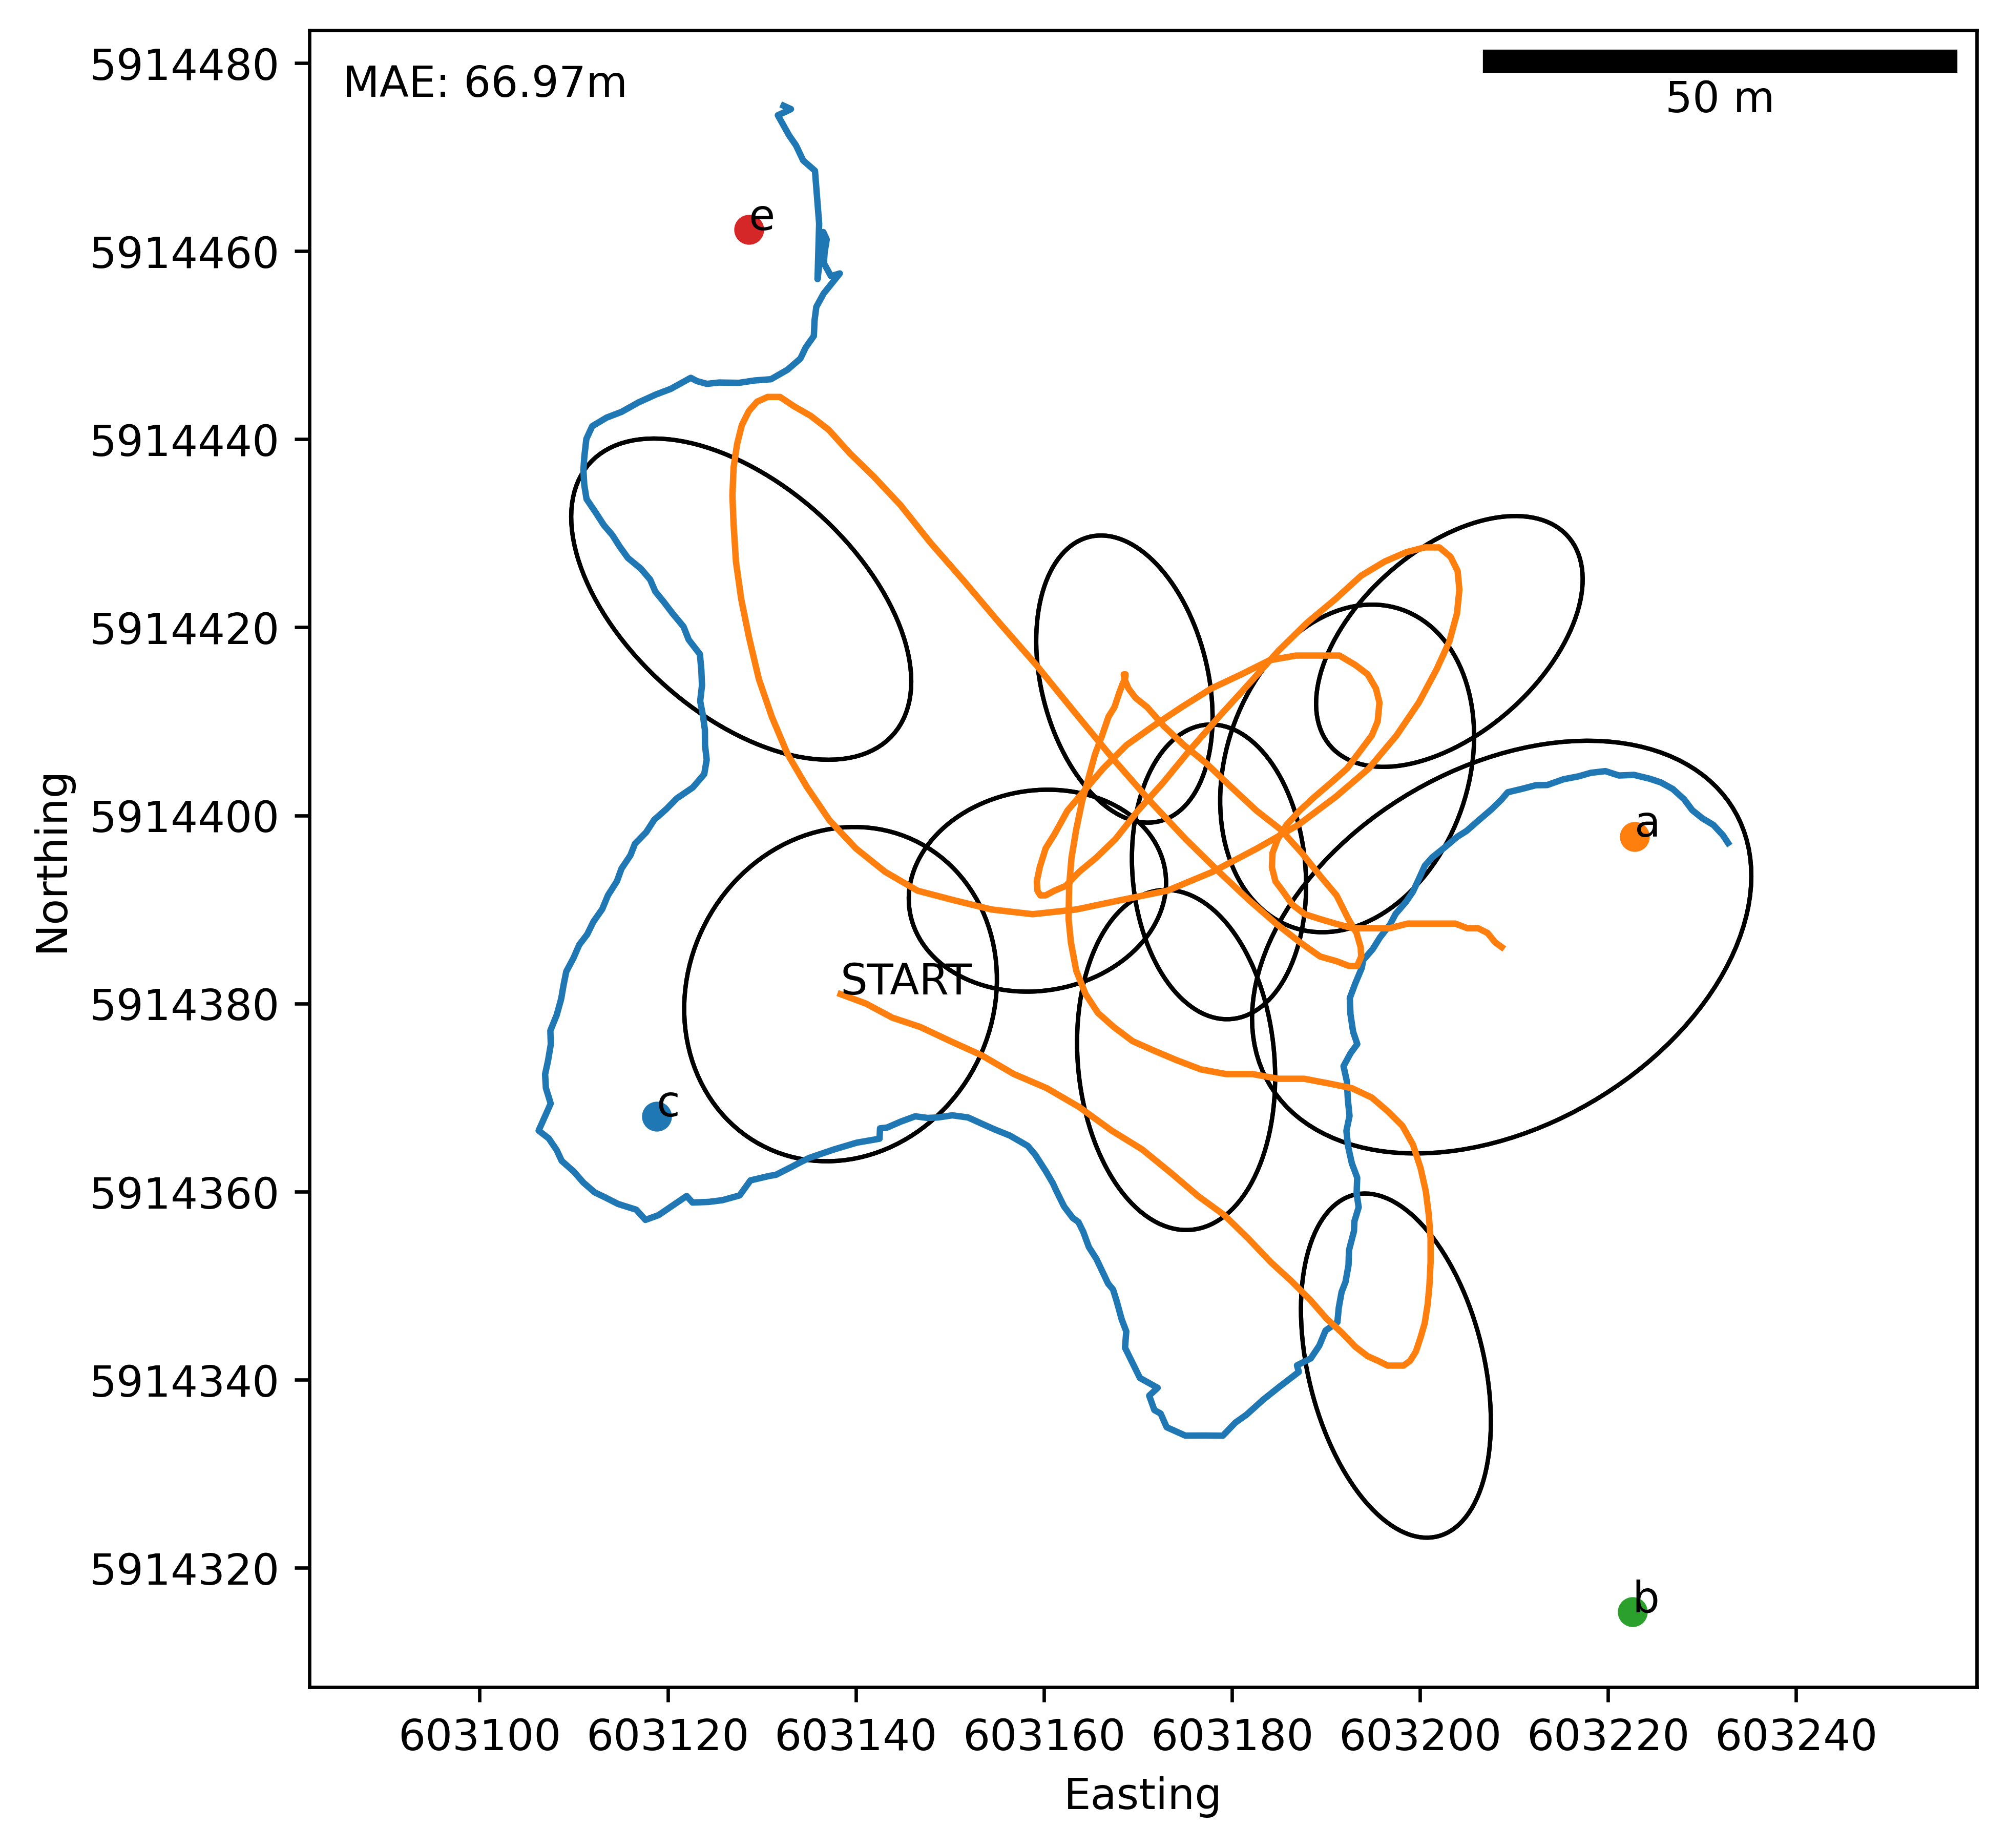

In [23]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

#plt.title("Path Inferred from Vectors (Rejection Sampling)")
ax1.legend_ = None
plt.savefig("path2.png")

# Using probability distribution

In [330]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=6**2)

for b in range(len(burst)):
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        obstimes.append(time[b])
        obs.append(burst[b])
        
# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

Standardising angles and times (shifting by 38.00 degrees)


In [332]:
# NOISE SCALE, INDUCING POINTS TODO : standardize order
k = EQIntegralKernel(0.5,0.5)
path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * margin, jitter = 1)
path.run(350,learning_rate=1, just_optimise_means = False)

Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  115395.0
iteration   50:   92298.5
iteration  100:   85975.9
iteration  150:   86026.8
iteration  200:   85938.3
iteration  250:   85884.4
iteration  300:   85949.5
Optimising mean and covariance...
iteration    0:   74071.1
iteration   50:   69518.1
iteration  100:   58075.5
iteration  150:   53173.2
iteration  200:   50139.7
iteration  250:   49770.8
iteration  300:   50286.4


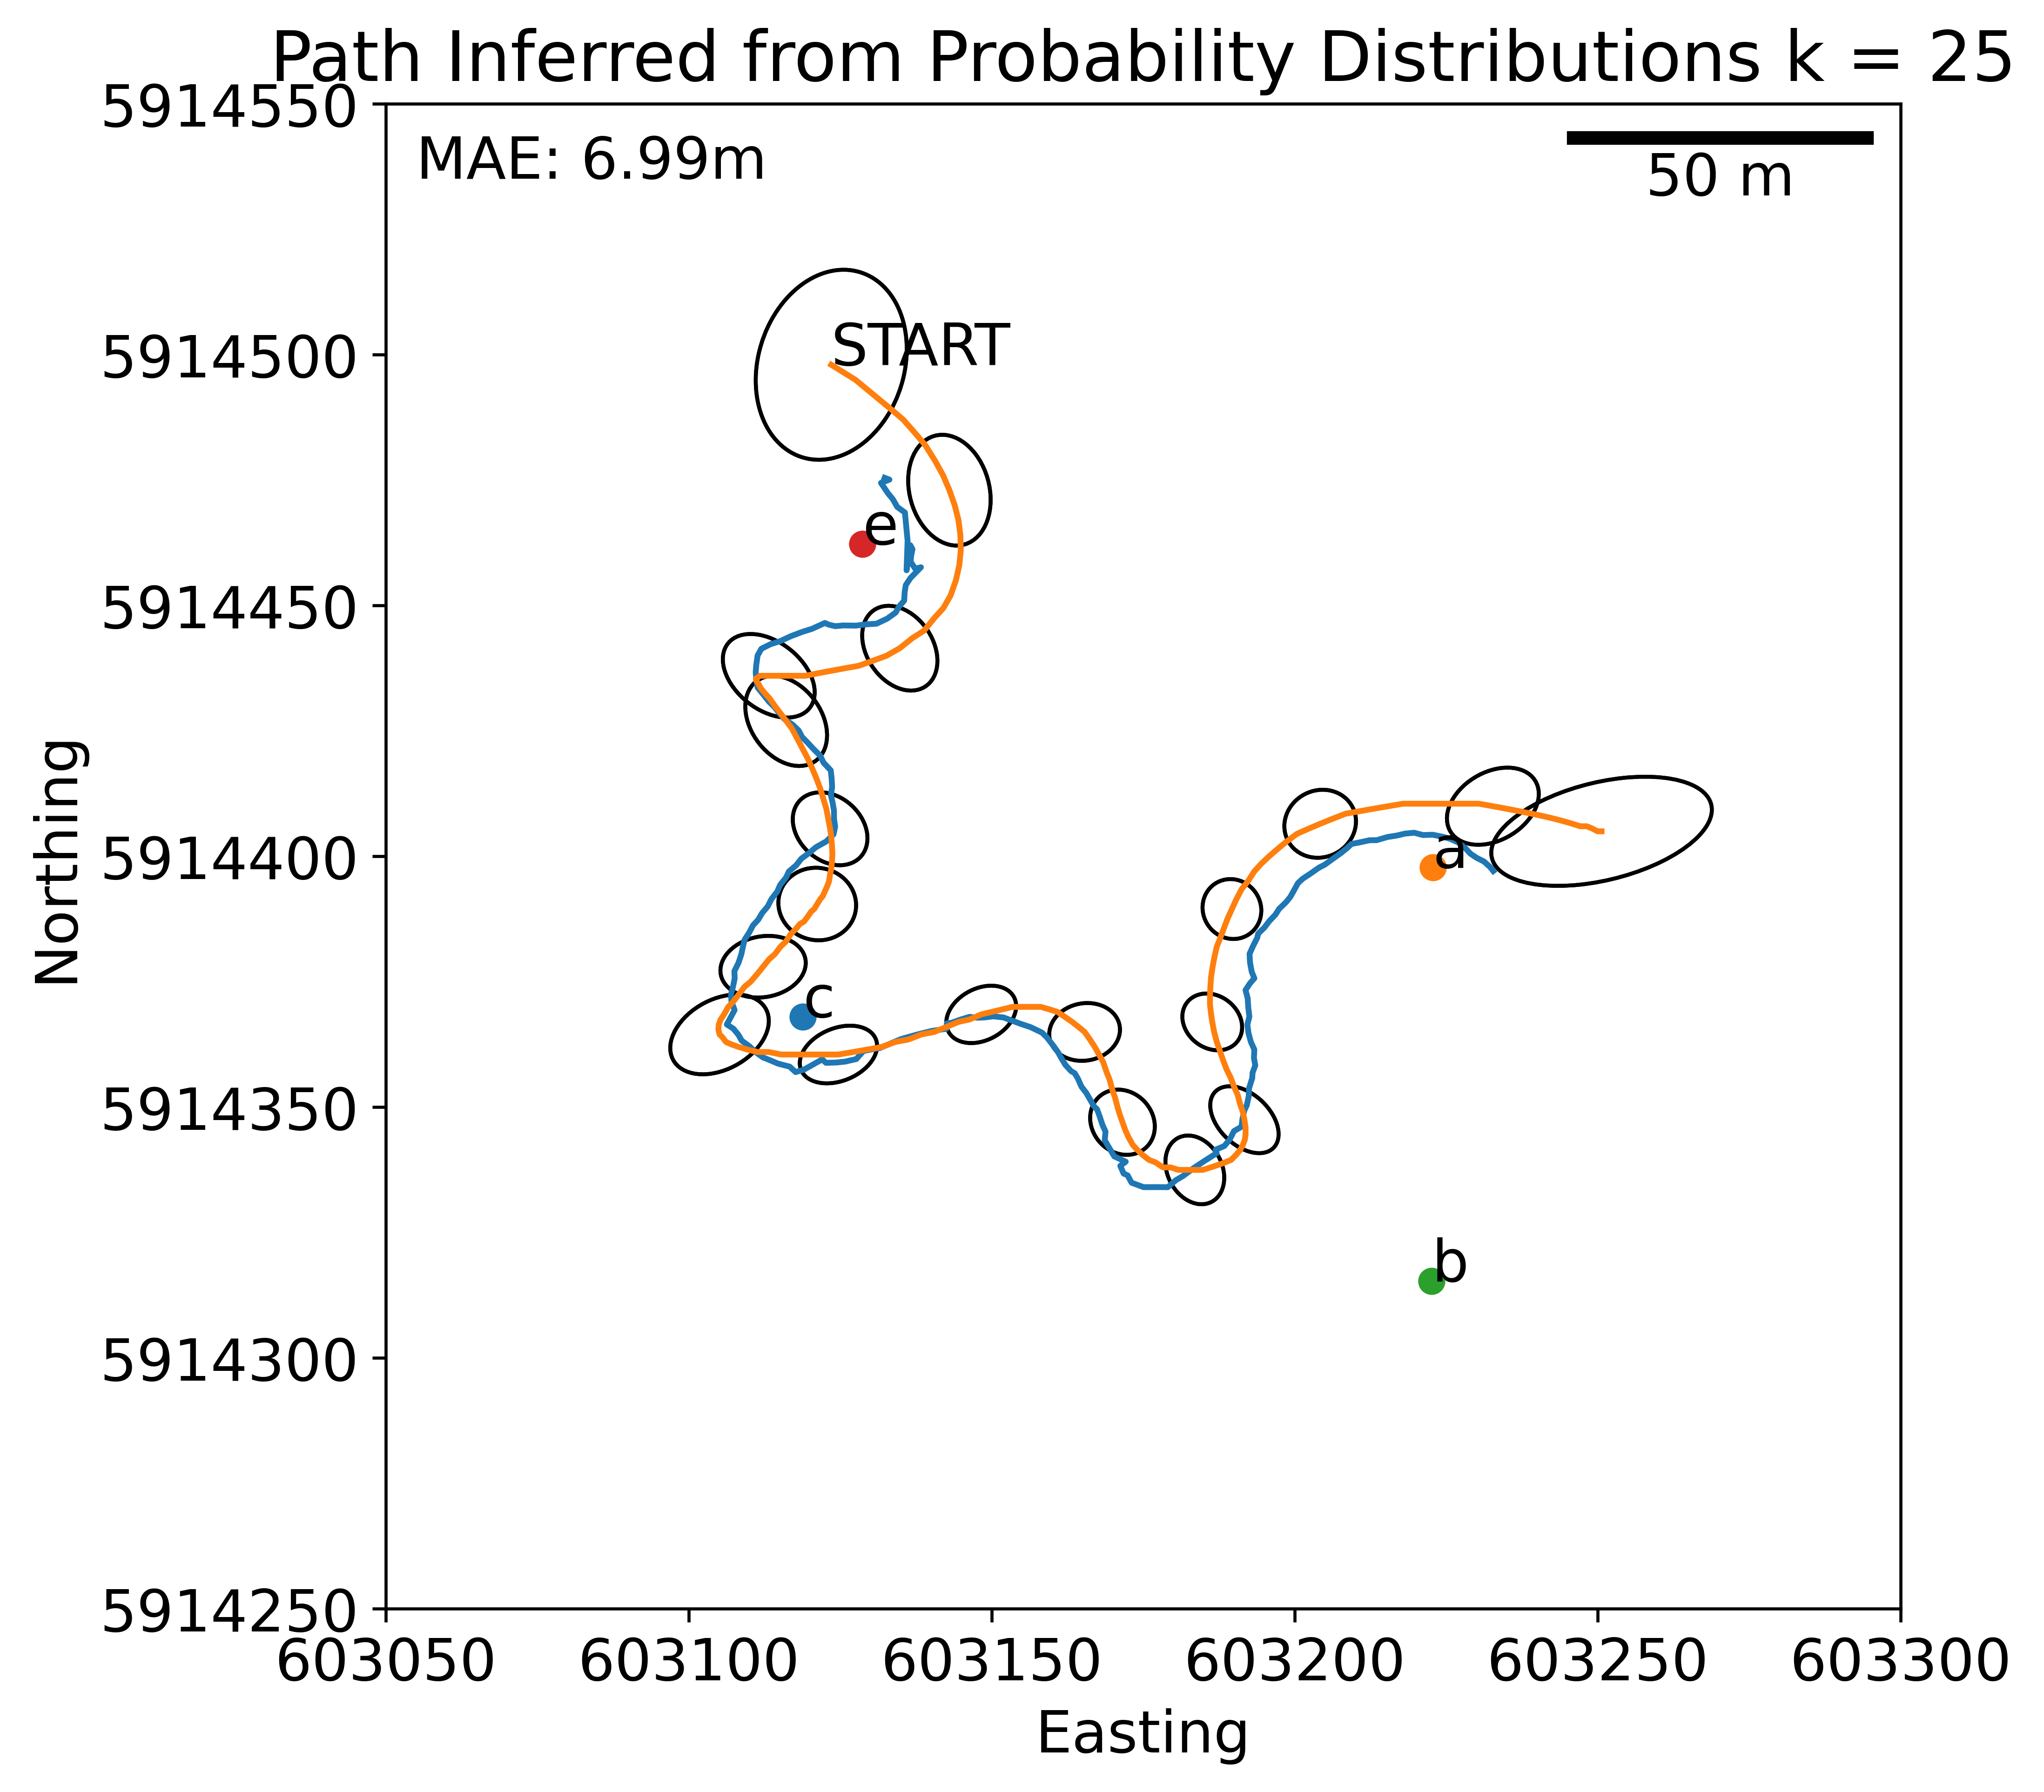

In [333]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval =20, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath, n_std = 3)
plt.title("Path Inferred from Probability Distributions k = " + str(nSamps))
ax1.legend_ = None
#ax1.set_adjustable('datalim')
plt.xlim(603050,603300)
plt.ylim(5914250,5914550)
plt.savefig("path3.png",bbox_inches='tight')

# Full Test

In [31]:
peakResults = []
fullProbResults = []

Standardising angles and times (shifting by 0.00 degrees)


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  535844.4
iteration   50:  473817.3
iteration  100:  469228.5
iteration  150:  468495.6
Optimising mean and covariance...
iteration    0:  465108.6
iteration   50:  448161.0
iteration  100:  439509.1
iteration  150:  434643.6


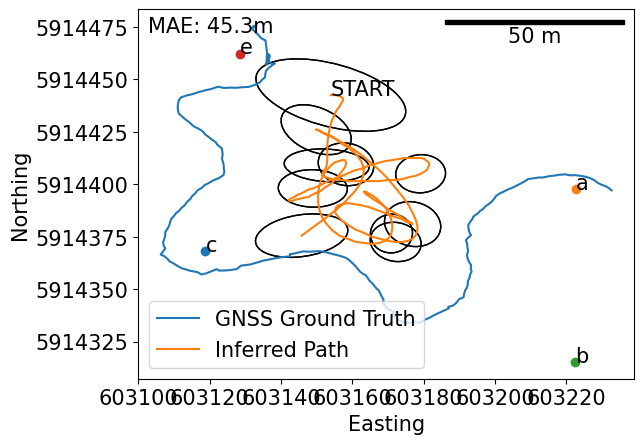

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   22765.7
iteration   50:    9740.1
iteration  100:    9343.4
iteration  150:    9349.5
iteration  200:    9351.6
iteration  250:    9340.8
iteration  300:    9351.6
iteration  350:    9339.9
iteration  400:    9350.4
iteration  450:    9350.2
Optimising mean and covariance...
iteration    0:    9231.4
iteration   50:    7567.6
iteration  100:    7041.3
iteration  150:    7113.9
iteration  200:    6564.9
iteration  250:    6699.8
iteration  300:    6342.4
iteration  350:    5820.6
Failed, reducing lr
Optimising mean...
iteration    0:   23143.3
iteration   50:    9628.9
iteration  100:    9454.1
iteration  150:    9461.7
iteration  200:    9458.5
iteration  250:    9460.2
iteration  300:    9454.3
iteration  350:    9450.7
Optimising mean and covariance...
iteration    0:    9574.5
iteration   50:    7926.8
iteration  100:    7581.8
it

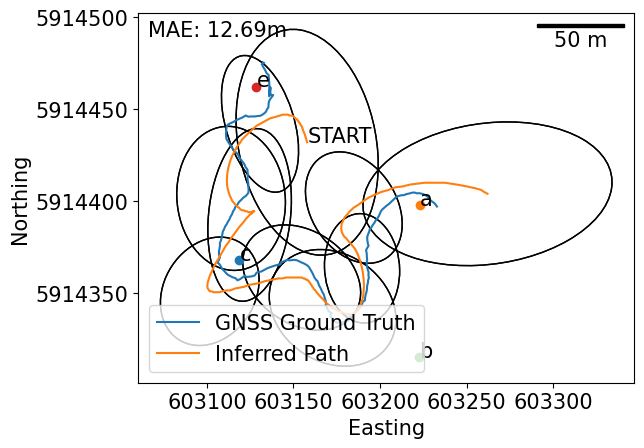

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  419155.7
iteration   50:  289148.8
iteration  100:  279244.8
iteration  150:  277234.2
Optimising mean and covariance...
iteration    0:  266937.2
iteration   50:  251382.0
iteration  100:  244752.0
iteration  150:  241464.6


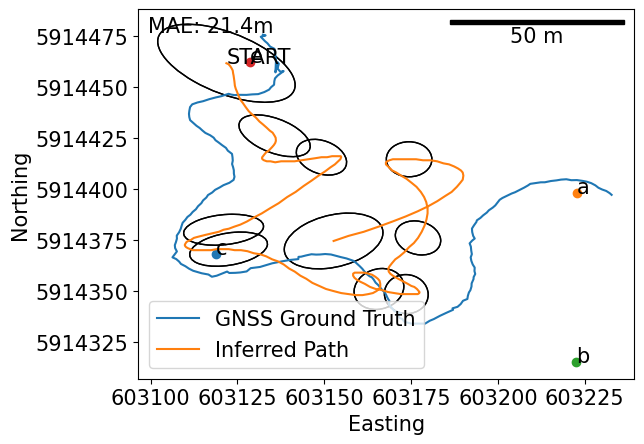

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   28660.6
iteration   50:   15587.9
iteration  100:   15299.2
iteration  150:   15312.9
iteration  200:   15308.7
iteration  250:   15290.1
iteration  300:   15301.9
iteration  350:   15303.6
iteration  400:   15303.2
iteration  450:   15298.6
Optimising mean and covariance...
iteration    0:   15179.9
iteration   50:   11259.9
iteration  100:   10610.4
iteration  150:   10044.1
iteration  200:    9418.1
iteration  250:    9322.3
iteration  300:    9199.8
iteration  350:    9422.6
iteration  400:    9193.6
iteration  450:    9999.3


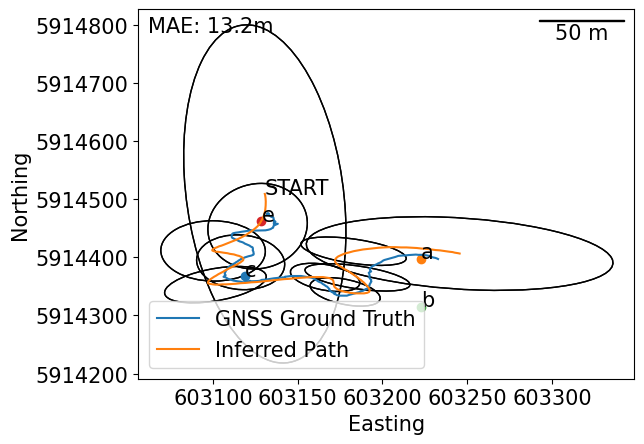

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  367173.1
iteration   50:  206261.7
iteration  100:  193584.1
iteration  150:  191471.2
Optimising mean and covariance...
iteration    0:  179493.8
iteration   50:  165426.1
iteration  100:  158876.8
iteration  150:  156235.5


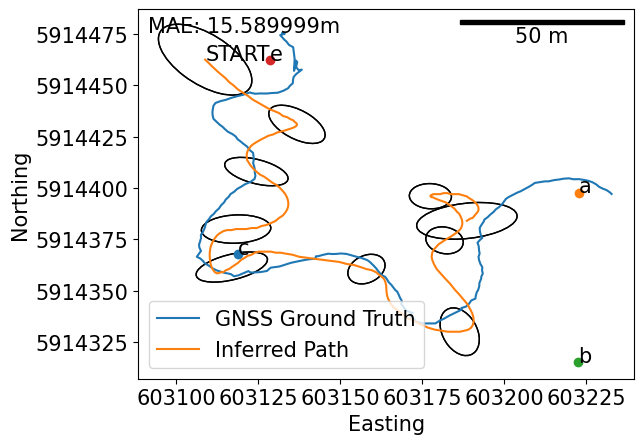

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   32633.3
iteration   50:   19304.8
iteration  100:   19021.9
iteration  150:   19037.8
iteration  200:   19030.6
iteration  250:   18994.8
iteration  300:   19029.7
iteration  350:   19019.3
iteration  400:   19035.4
iteration  450:   19029.8
Optimising mean and covariance...
iteration    0:   18530.3
iteration   50:   14235.3
iteration  100:   13390.9
iteration  150:   12706.5
iteration  200:   12832.8
iteration  250:   11776.1
iteration  300:   10949.0
iteration  350:   11769.3
iteration  400:   10889.8
Failed, reducing lr
Optimising mean...
iteration    0:   32720.9
iteration   50:   19239.2
iteration  100:   19039.8
iteration  150:   19027.4
iteration  200:   19028.3
iteration  250:   19033.1
iteration  300:   19030.0
iteration  350:   19013.3
Optimising mean and covariance...
iteration    0:   18924.6
iteration   50:   14403.2
it

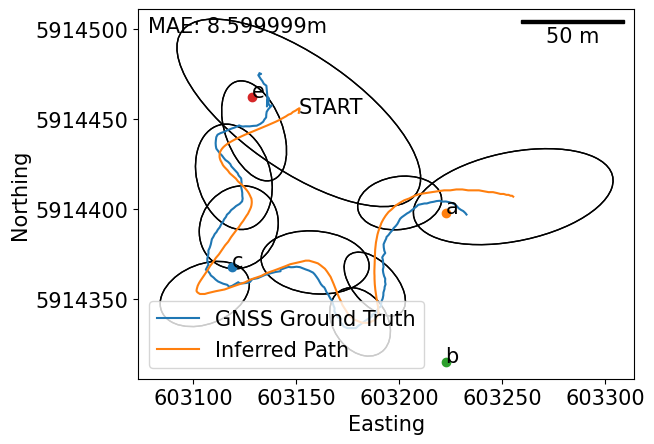

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  351392.9
iteration   50:  156992.8
iteration  100:  140567.7
iteration  150:  138071.2
Optimising mean and covariance...
iteration    0:  122839.6
iteration   50:  111087.2
iteration  100:  103419.4
iteration  150:  101827.8


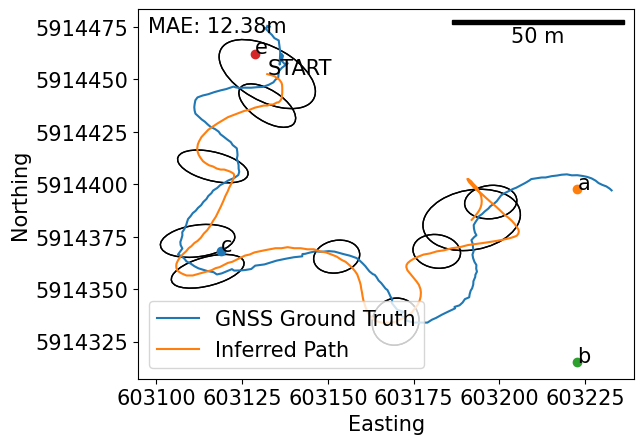

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   38655.2
iteration   50:   25033.8
iteration  100:   24702.8
iteration  150:   24710.2
iteration  200:   24701.8
iteration  250:   24681.5
iteration  300:   24694.5
iteration  350:   24702.8
iteration  400:   24701.6
iteration  450:   24680.7
Optimising mean and covariance...
iteration    0:   24549.7
iteration   50:   18720.0
iteration  100:   17458.9
Failed, reducing lr
Optimising mean...
iteration    0:   39225.9
iteration   50:   24896.6
iteration  100:   24693.2
iteration  150:   24670.7
iteration  200:   24700.4
iteration  250:   24683.9
iteration  300:   24718.6
iteration  350:   24688.1
Optimising mean and covariance...
iteration    0:   24886.1
iteration   50:   18873.4
iteration  100:   16596.1
iteration  150:   15072.3
iteration  200:   14383.3
iteration  250:   13942.1
iteration  300:   13611.8
iteration  350:   13263.5


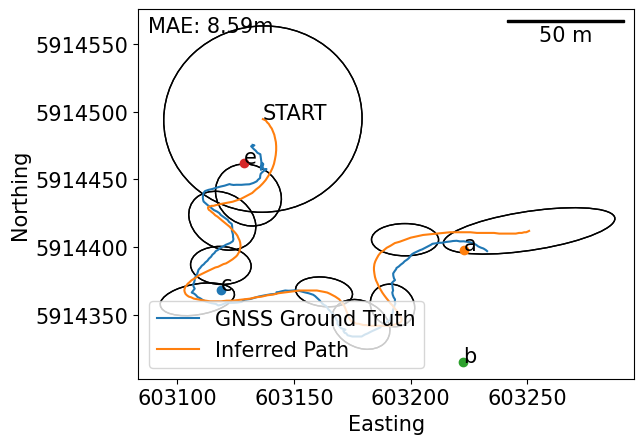

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  302164.4
iteration   50:  113945.8
iteration  100:   98144.9
iteration  150:   95669.4
Optimising mean and covariance...
iteration    0:   81298.3
iteration   50:   70487.3
iteration  100:   63192.0
iteration  150:   61380.4


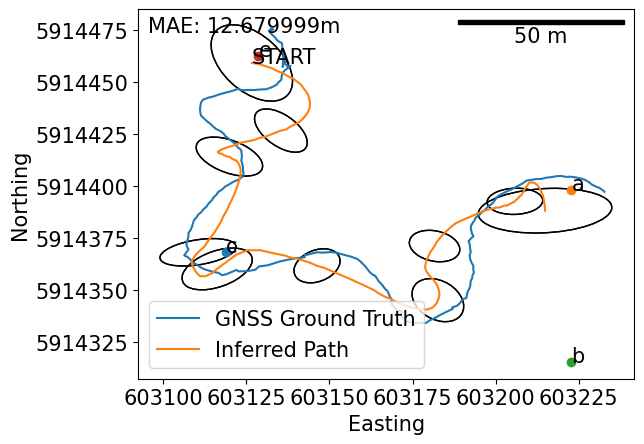

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   46799.3
iteration   50:   32843.3
iteration  100:   32549.9
iteration  150:   32568.2
iteration  200:   32581.6
iteration  250:   32561.8
iteration  300:   32568.0
iteration  350:   32580.4
iteration  400:   32572.9
iteration  450:   32564.6
Optimising mean and covariance...
iteration    0:   32088.8
iteration   50:   25434.1
iteration  100:   21786.1
iteration  150:   20342.8
iteration  200:   19830.2
iteration  250:   18350.2
iteration  300:   18336.6
iteration  350:   17755.5
iteration  400:   17768.3
iteration  450:   17850.7


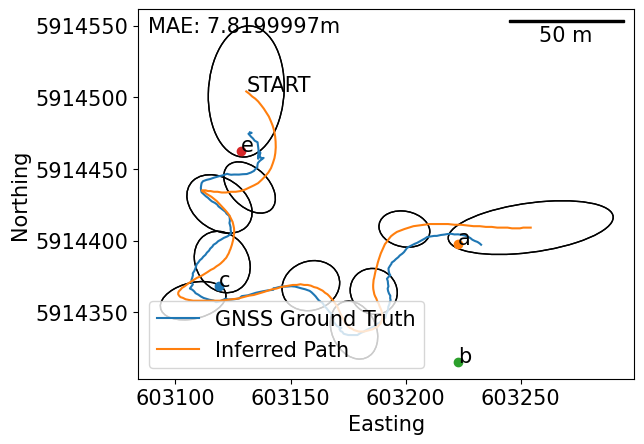

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  317813.8
iteration   50:  106133.7
iteration  100:   87871.2
iteration  150:   84966.9
Optimising mean and covariance...
iteration    0:   67601.2
iteration   50:   56593.8
iteration  100:   48981.9
iteration  150:   46993.4


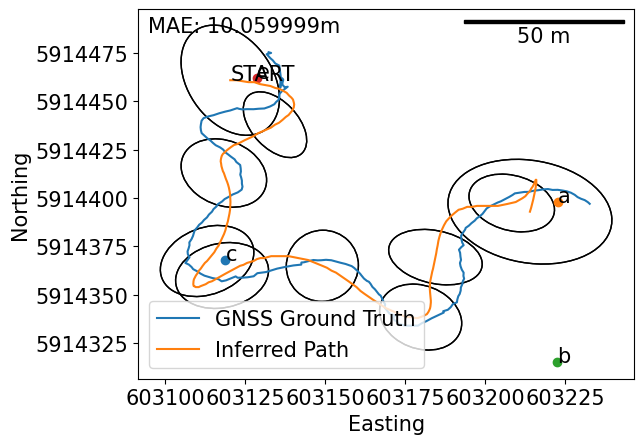

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   56298.9
iteration   50:   42161.1
iteration  100:   41811.9
iteration  150:   41829.0
iteration  200:   41830.8
iteration  250:   41803.0
iteration  300:   41820.6
iteration  350:   41850.1
iteration  400:   41844.4
iteration  450:   41802.7
Optimising mean and covariance...
iteration    0:   41222.1
iteration   50:   30427.4
iteration  100:   26464.6
iteration  150:   24028.3
iteration  200:   22936.4
iteration  250:   22308.9
iteration  300:   22080.2
iteration  350:   23730.0
iteration  400:   22160.6
iteration  450:   21683.4


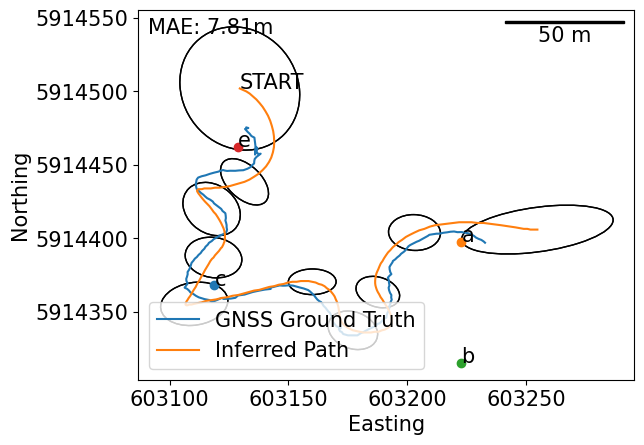

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  308354.6
iteration   50:   95498.4
iteration  100:   78409.9
iteration  150:   75420.4
Optimising mean and covariance...
iteration    0:   57695.2
iteration   50:   46658.8
iteration  100:   37791.6
iteration  150:   36334.7


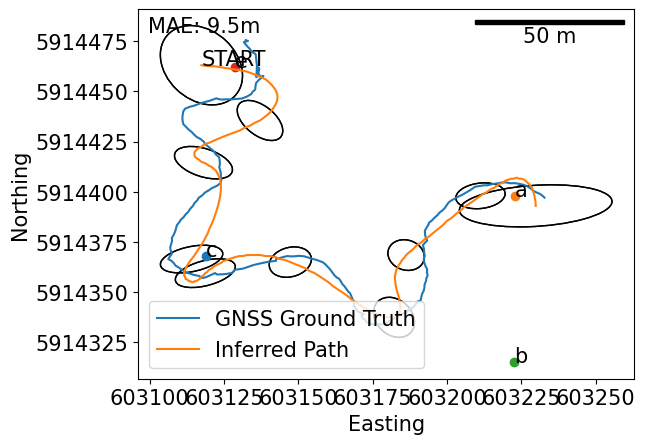

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   75222.9
iteration   50:   59384.6
iteration  100:   58784.5
iteration  150:   58849.0
iteration  200:   58833.8
iteration  250:   58793.8
iteration  300:   58818.4
iteration  350:   58822.9
iteration  400:   58815.4
iteration  450:   58793.2
Optimising mean and covariance...
iteration    0:   56797.2
iteration   50:   42730.3
iteration  100:   37780.0
iteration  150:   34550.0
iteration  200:   32901.0
iteration  250:   32145.7
iteration  300:   31861.0
iteration  350:   31758.9
iteration  400:   32143.5
iteration  450:   31449.5


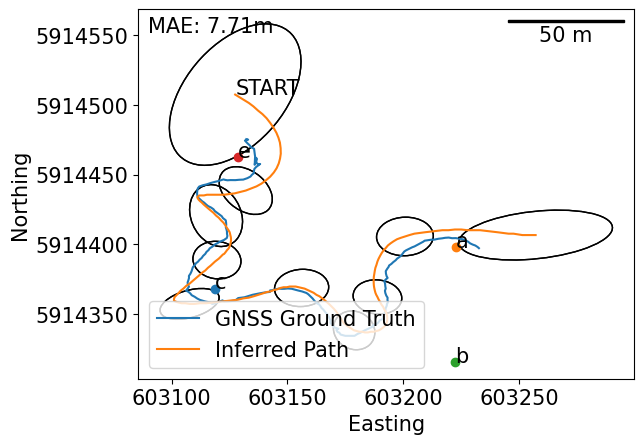

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  315341.5
iteration   50:   96967.8
iteration  100:   78969.5
iteration  150:   75855.4
Optimising mean and covariance...
iteration    0:   57374.6
iteration   50:   45905.5
iteration  100:   37485.0
iteration  150:   35482.8


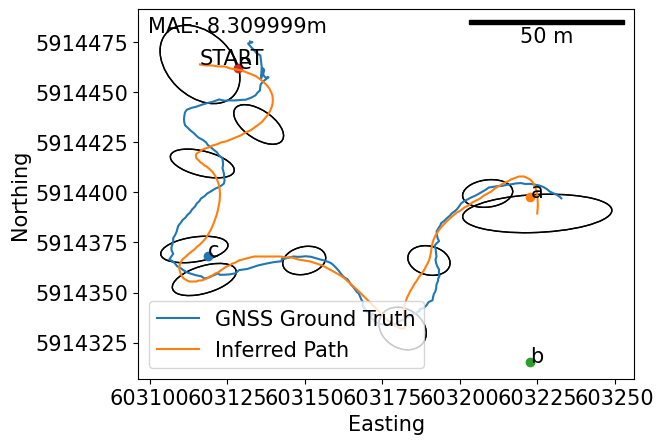

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   95962.2
iteration   50:   77013.6
iteration  100:   76315.7
iteration  150:   76200.5
iteration  200:   76158.5
iteration  250:   76108.7
iteration  300:   76163.4
iteration  350:   76176.9
iteration  400:   76189.2
iteration  450:   76143.5
Optimising mean and covariance...
iteration    0:   73303.8
iteration   50:   57780.1
iteration  100:   51763.0
iteration  150:   45482.8
iteration  200:   43212.3
iteration  250:   43955.2
iteration  300:   42750.2
iteration  350:   41538.1
iteration  400:   41921.5
iteration  450:   42104.7


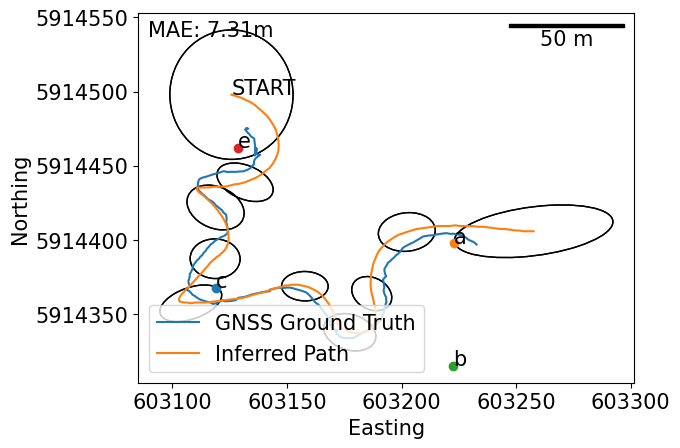

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  310100.4
iteration   50:   94228.0
iteration  100:   76126.6
iteration  150:   73104.7
Optimising mean and covariance...
iteration    0:   54867.7
iteration   50:   43632.0
iteration  100:   35518.1
iteration  150:   33931.1


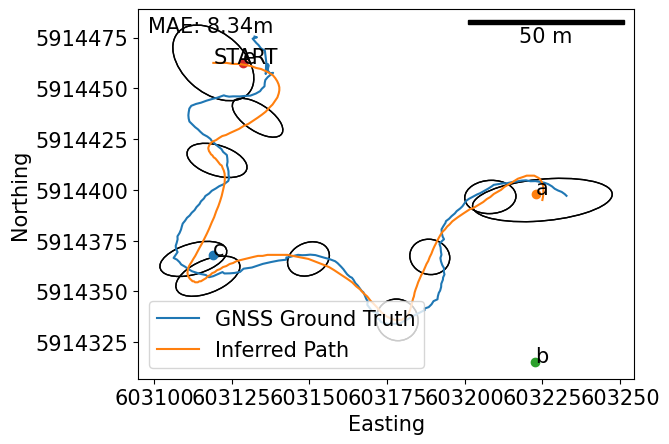

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  115395.0
iteration   50:   92298.5
iteration  100:   85975.9
iteration  150:   86026.8
iteration  200:   85938.3
iteration  250:   85884.4
iteration  300:   85949.5
iteration  350:   85940.7
iteration  400:   85975.8
iteration  450:   85943.2
Optimising mean and covariance...
iteration    0:   73217.1
iteration   50:   68940.8
iteration  100:   56326.9
iteration  150:   51351.8
iteration  200:   51836.3
iteration  250:   50228.9
iteration  300:   49401.9
iteration  350:   49367.6
iteration  400:   50203.6
iteration  450:   49761.6


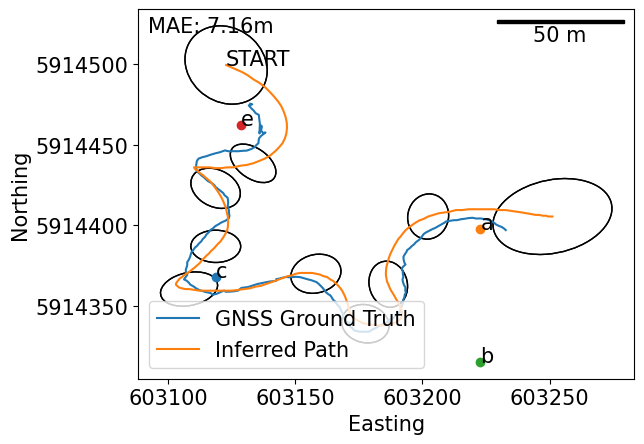

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  312585.4
iteration   50:   95921.4
iteration  100:   78261.6
iteration  150:   75193.6
Optimising mean and covariance...
iteration    0:   57314.8
iteration   50:   46188.3
iteration  100:   37073.9
iteration  150:   35548.9


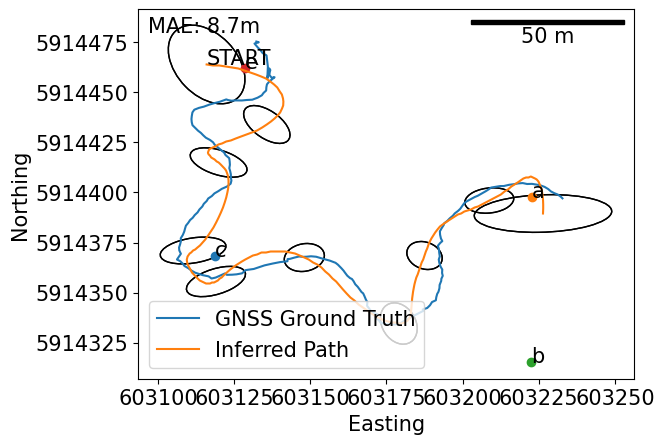

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  202208.9
iteration   50:  155619.0
iteration  100:  148641.9
iteration  150:  142536.5
iteration  200:  142381.1
iteration  250:  142261.5
iteration  300:  142361.9
Failed, reducing lr
Optimising mean...
iteration    0:  209826.2
iteration   50:  156650.1
iteration  100:  146098.0
iteration  150:  142568.1
iteration  200:  142342.4
Failed, reducing lr
Optimising mean...
iteration    0:  217680.5
iteration   50:  156288.3
iteration  100:  149096.5
iteration  150:  142505.4
iteration  200:  142359.5
iteration  250:  142274.0
Optimising mean and covariance...
iteration    0:  136750.5
iteration   50:  116701.9
iteration  100:  100763.9
iteration  150:   94311.6
iteration  200:   93451.8
iteration  250:   91016.9


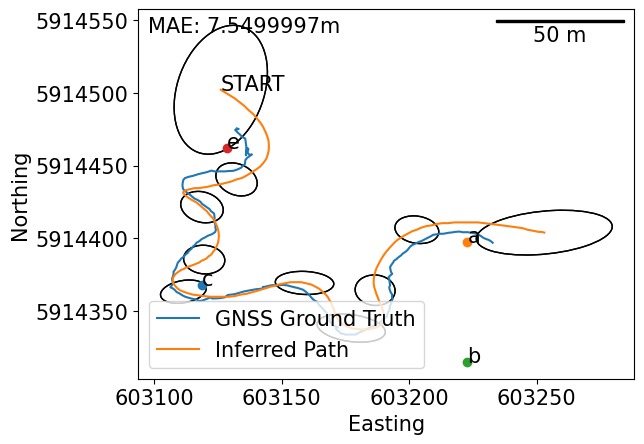

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0:  314985.2
iteration   50:   96309.3
iteration  100:   78175.5
iteration  150:   75090.2
Optimising mean and covariance...
iteration    0:   57228.3
iteration   50:   46381.3
iteration  100:   37253.0
iteration  150:   35691.4


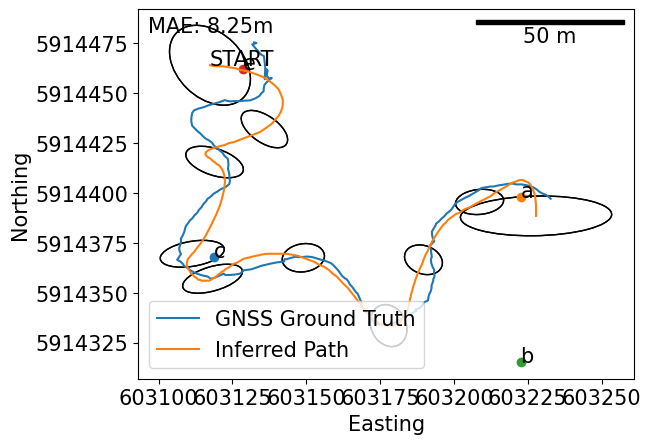

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  323723.0
iteration   50:  240351.7
Failed, reducing lr
Optimising mean...
iteration    0:  330481.1
iteration   50:  244033.4
iteration  100:  219220.3
iteration  150:  216412.2
iteration  200:  216149.1
iteration  250:  216012.7
iteration  300:  216036.6
iteration  350:  216017.7
Optimising mean and covariance...
iteration    0:  211132.8
iteration   50:  184126.3
iteration  100:  153913.8
iteration  150:  142577.8
iteration  200:  136363.7
iteration  250:  135153.7
iteration  300:  134963.6
iteration  350:  133847.3


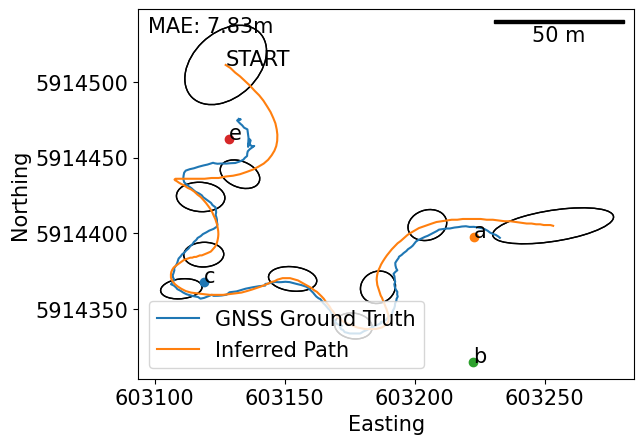

In [35]:
pathIndex = 2
kSamps = [3,4,5,6,8,10,15,20,25,50,100]
k = EQIntegralKernel(0.5,0.5)

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = paths[pathIndex][2]
endingTime = paths[pathIndex][3]


currentpeakResults = []
currentrejectionResults = []
currentfullProbResults = []

testdata = Signals(paths[pathIndex][0],['c','a','b','e'],filetype='log',angleOffset=0)
GPSfilepath = paths[pathIndex][1]
testdata.configureTransmitter('c',0,np.deg2rad(15),transmitterLat = 53.368359, transmitterLon = -1.450168)
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
testdata.configureTransmitter('b',-(167340+194210+121110),-np.deg2rad(15),transmitterLat = 53.367865, transmitterLon = -1.448626)
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()

for nSamps in kSamps:
    # ---------- PEAK FINDING ----------
    
    obs = []
    obstimes = []
    
    # Get packet bursts from data
    burst, time = testdata.parseBursts(burstInterval=0)
    angles = AnglesUsePeaks(windowLength=3)
    
    # For each burst
    for b in range(len(burst)):
        # Infer an angle
        burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
        # If a peak was found
        if not (np.isnan(prediction)):
            # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
            # Add time of observation
            obstimes.append(time[b])
    
    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale
    
    path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 1)
    inferred = False
    while inferred == False:
        path.run(200,learning_rate=1, just_optimise_means = False)
    
        if(np.isnan(path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)) == False):
            inferred = True
    plt.show()
    currentpeakResults.append(path)
    
    # ---------- FULL PROB DIST ----------
    obs = []
    obstimes = []
    burst, time = testdata.parseBursts(burstInterval=0)
    anglesPattern = AnglesUsePatternMeans(noisevar=6**2)
    
    for b in range(len(burst)):
        burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
        ps = normalise_logs_to_ps(logps)
        prediction = np.argmax(ps)
        if not (np.isnan(prediction)):
            obstimes.append(time[b])
            obs.append(burst[b])
            
    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale
    
    path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * margin, jitter = 1)
    inferred = False
    nInter = 500
    while inferred != True:
        try:
            path.run(nInter,learning_rate=1, just_optimise_means = False)
            inferred = True
        except:
            print("Failed, reducing lr")
            nInter = nInter - 100
    currentfullProbResults.append(path)
    path.plot(startTime = startingTime, endTime = endingTime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 10, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = GPSfilepath)
    plt.show()
    
    
peakResults.append(currentpeakResults)
fullProbResults.append(currentfullProbResults)

[Array(38.90476, dtype=float32),
 Array(22.911629, dtype=float32),
 Array(18.103083, dtype=float32),
 Array(14.669247, dtype=float32),
 Array(9.709593, dtype=float32),
 Array(8.045928, dtype=float32),
 Array(7.3408146, dtype=float32),
 Array(6.914012, dtype=float32),
 Array(7.2061057, dtype=float32),
 Array(7.6031394, dtype=float32),
 Array(7.076629, dtype=float32)]

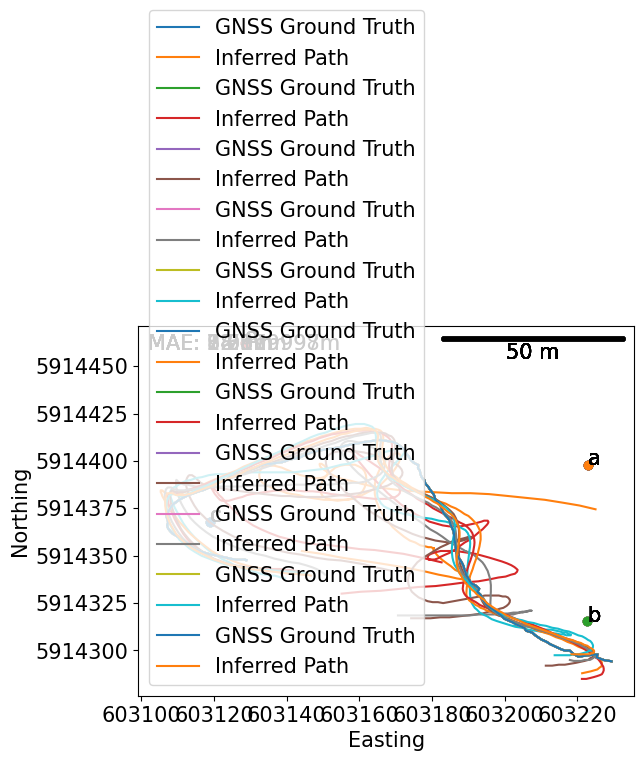

In [33]:
[x.plot(startTime = paths[0][2], endTime = paths[0][3], 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in peakResults[0]]

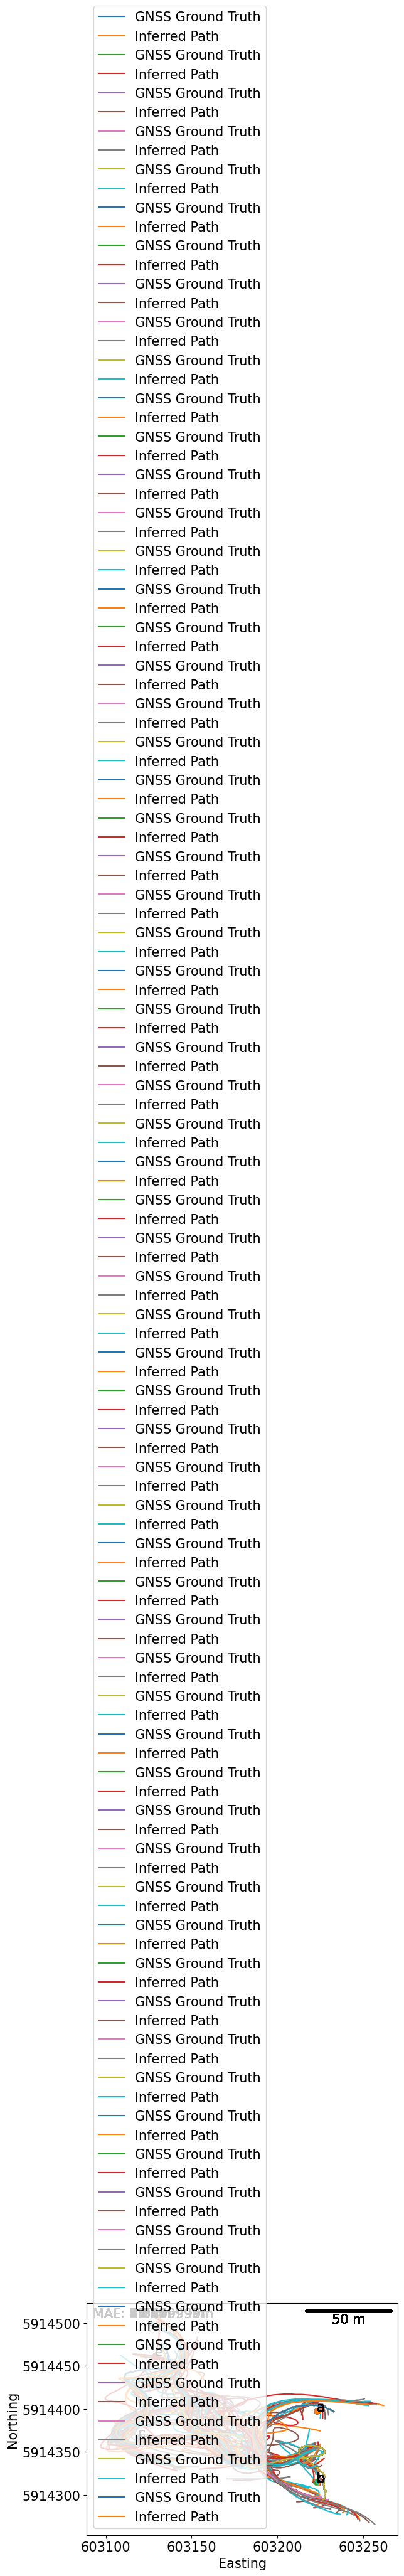

In [36]:
# ---- Peak MAE Summing ----
path1 = [x.plot(startTime = paths[0][2], endTime = paths[0][3], 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in peakResults[0]]
path2 = [x.plot(startTime = paths[1][2], endTime = paths[1][3],  
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[1][1]) for x in peakResults[1]]
path3 = [x.plot(startTime = paths[2][2], endTime = paths[2][3],  
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[2][1]) for x in peakResults[2]]
peakMAE = np.sum([path1,path2,path3], axis=0)/3
peakSTD = np.std([path1,path2,path3], axis=0)

# ---- Peak MAE Summing ----
path1 = [x.plot(startTime = paths[0][2], endTime = paths[0][3], 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in fullProbResults[0]]
path2 = [x.plot(startTime = paths[1][2], endTime = paths[1][3],  
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[1][1]) for x in fullProbResults[1]]
path3 = [x.plot(startTime = paths[2][2], endTime = paths[2][3],  
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[2][1]) for x in fullProbResults[2]]

fullprobMAE = np.sum([path1,path2,path3], axis=0)/3
fullprobSTD = np.std([path1,path2,path3], axis=0)

In [163]:
peakMAE

array([13.894211, 11.593189, 10.31926 , 10.303517,  9.837418,  9.804737,
       10.139436, 10.461127], dtype=float32)

In [1009]:


with open("rejectionSampPathResultsMAE", "wb") as fp:
    pickle.dump(rejectionMAE, fp)
with open("peakFindingPathResultsMAE", "wb") as fp:
    pickle.dump(peakMAE, fp)
with open("fullProbabilityPathResultsMAE", "wb") as fp:
    pickle.dump(fullprobMAE, fp)
with open("rejectionSampPathResultsSTD", "wb") as fp:
    pickle.dump(rejectionSTD, fp)
with open("peakFindingPathResultsSTD", "wb") as fp:
    pickle.dump(peakSTD, fp)
with open("fullProbabilityPathResultsSTD", "wb") as fp:
    pickle.dump(fullprobSTD, fp)

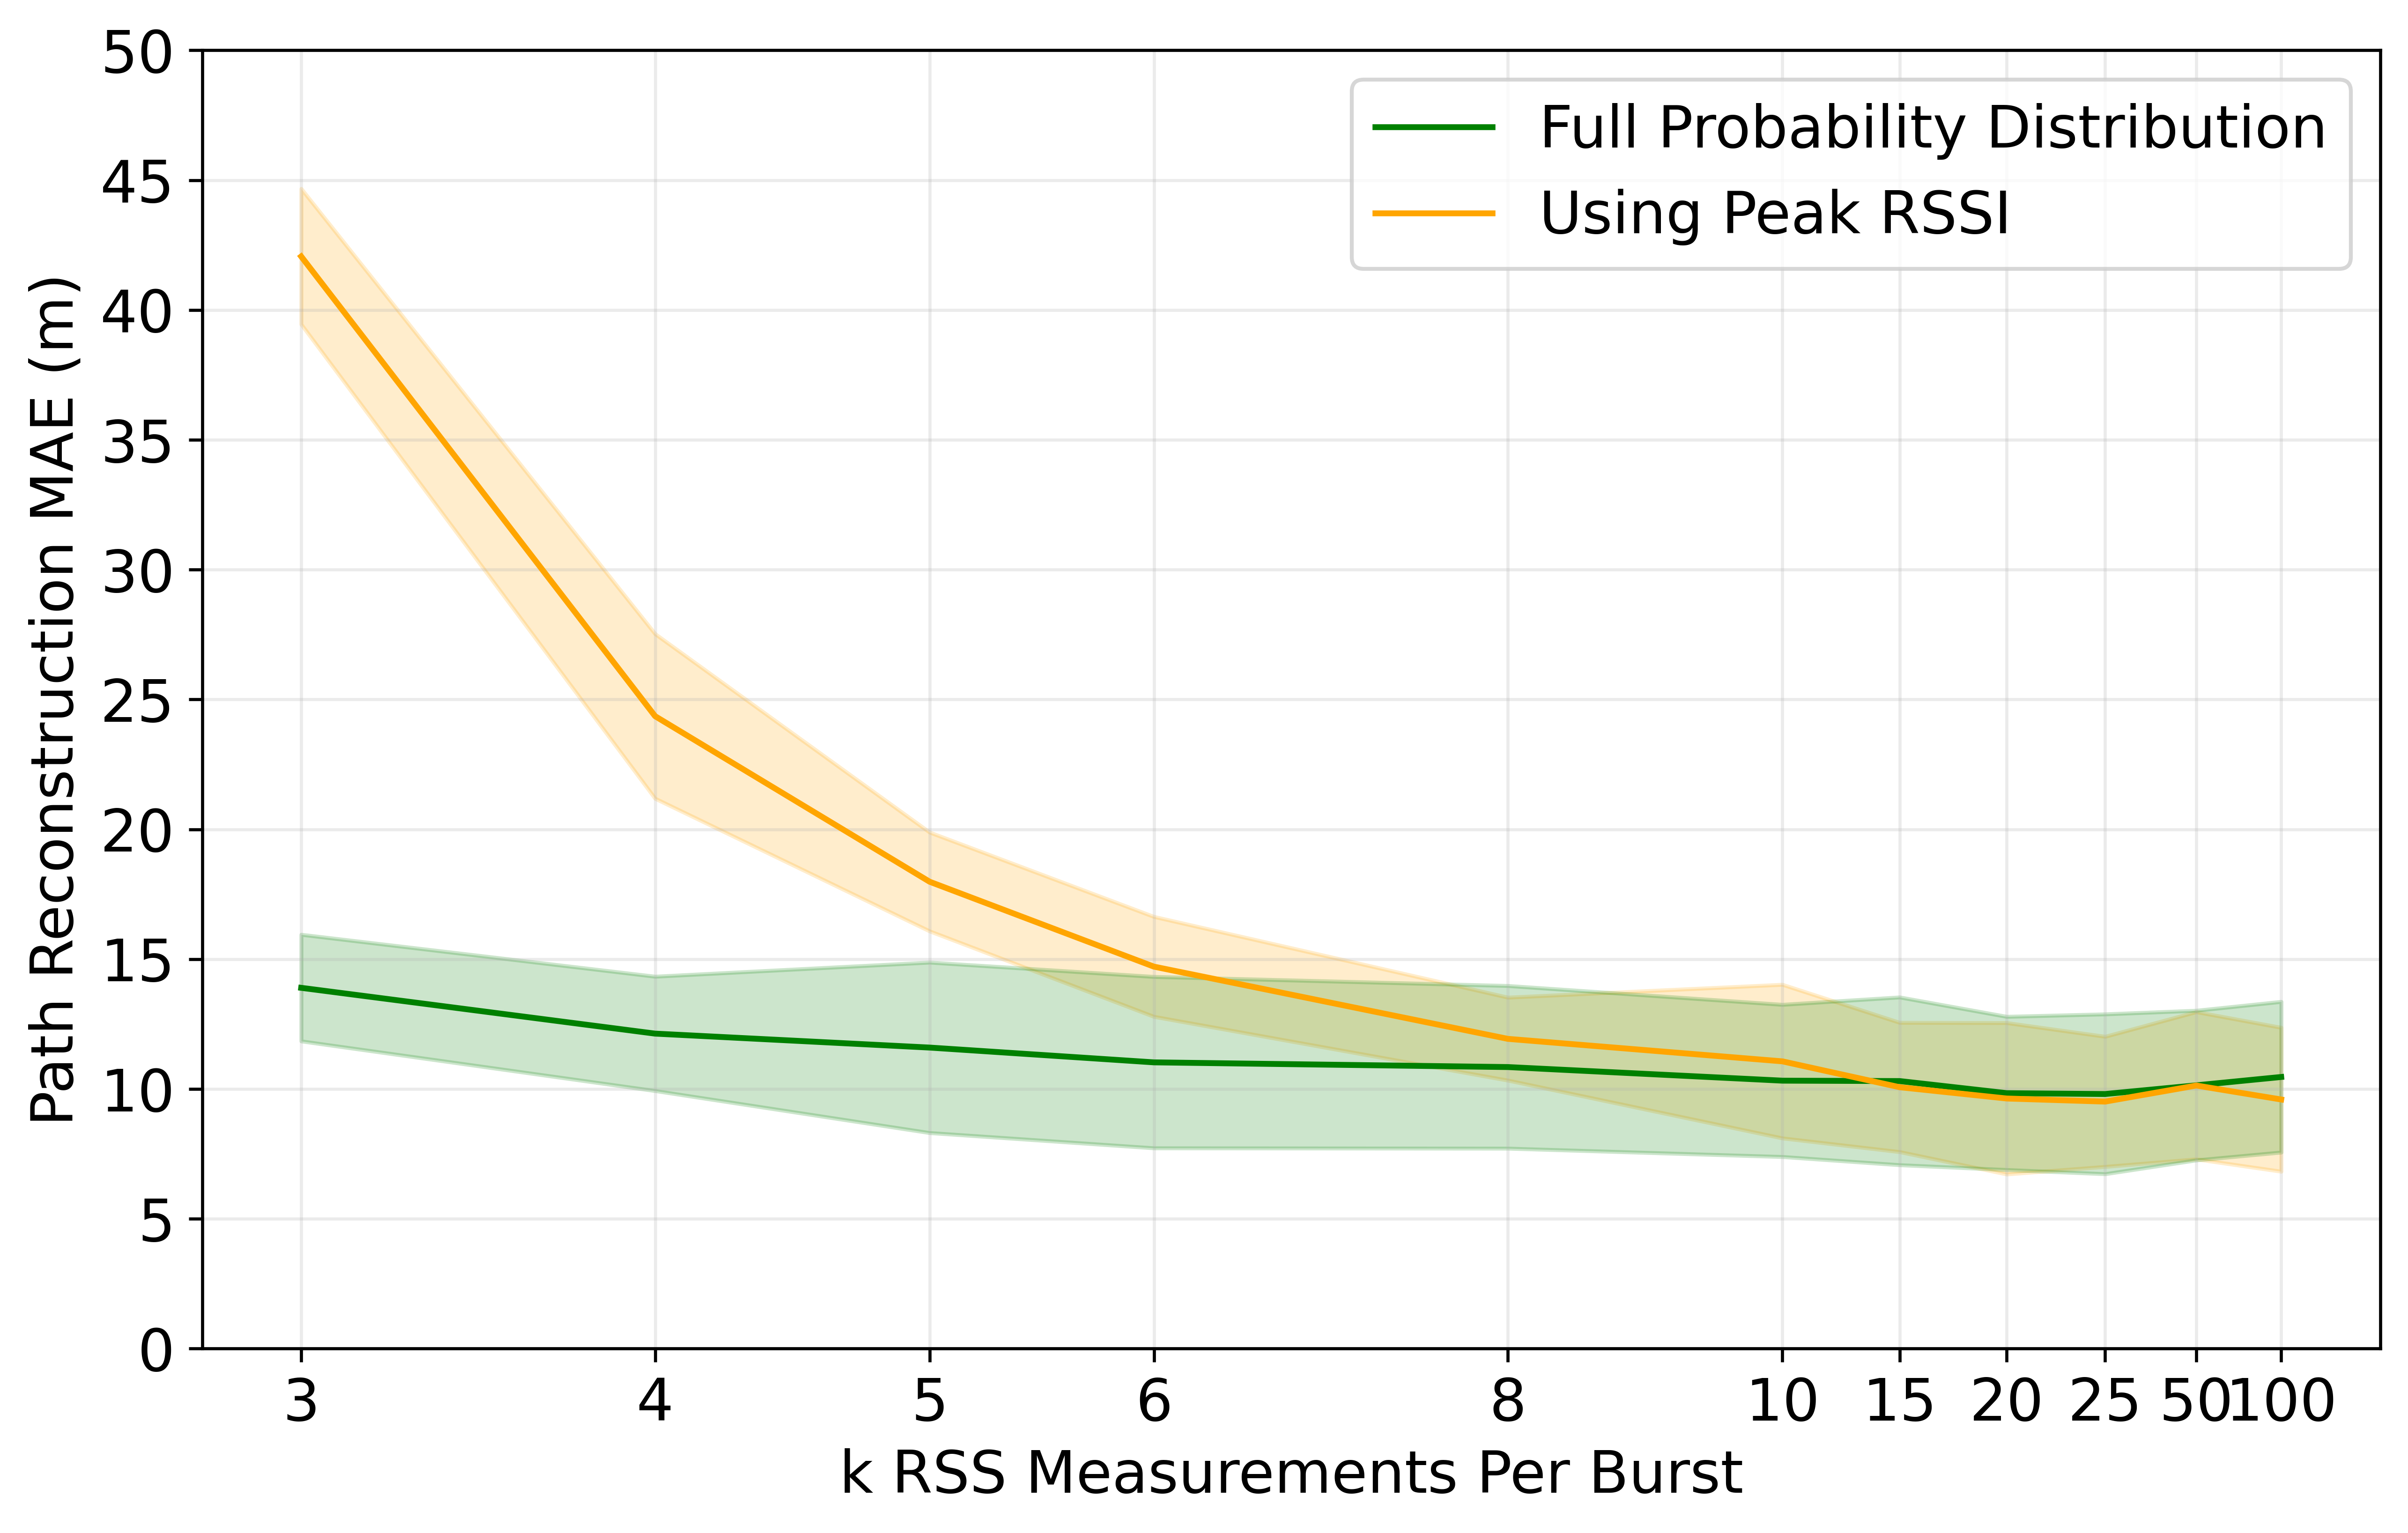

In [85]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(figsize=(10,6),dpi=600)
#kSamps = [3,4,5,6,8,10,15,20,25,50,100]
kSamps = [3,4,5,6,8,10,11,12,13,14,15]


plt.plot(kSamps, fullprobMAE, color="green", label="Full Probability Distribution")
plt.plot(kSamps, peakMAE,color="orange", label = "Using Peak RSSI")
plt.xscale("log", base = 2)
plt.ylim(0,50)
plt.xticks(kSamps, [str(t) for t in kSamps])
plt.xlabel("k RSS Measurements Per Burst")
plt.ylabel("Path Reconstruction MAE (m)")
ax1.fill_between(
    kSamps,
    [m + s for m, s in zip(peakMAE, peakSTD)],
    [m - s for m, s in zip(peakMAE, peakSTD)],
    color="orange",
    alpha=0.2,
)
ax1.fill_between(
    kSamps,
    [m + s for m, s in zip(fullprobMAE, fullprobSTD)],
    [m - s for m, s in zip(fullprobMAE, fullprobSTD)],
    color="green",
    alpha=0.2,
)
plt.legend()
ax1.grid(alpha=0.25)
ax1.set_xticklabels([3,4,5,6,8,10,15,20,25,50,100])
plt.yticks([0,5,10,15,20,25,30,35,40,45,50])
plt.savefig("4.png")
plt.show()

# Using vectors sampled from probability distribution (not assessed in paper)

In [45]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=10**2)
    
for b in range(len(burst)):
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        if np.sum(np.log(ps)*ps) > -5.5:
            prediction = np.deg2rad(prediction)
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
            obstimes.append(time[b])

print("Filtered down to " + str(len(obs)) + " packets.")

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale


Standardising angles and times (shifting by 38.00 degrees)
Filtered down to 282 packets.


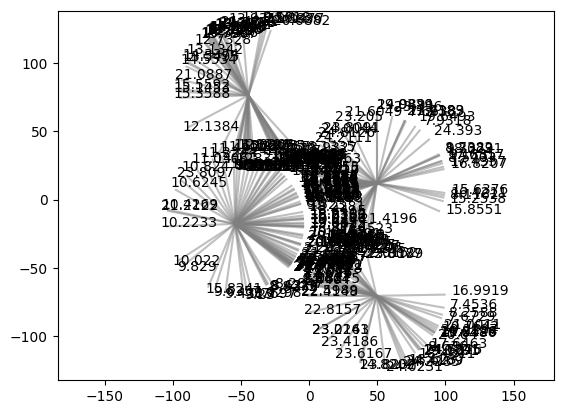

In [46]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [49]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 0.01)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0:  261835.8
iteration   50:   98295.5
iteration  100:   87683.9
iteration  150:   86287.9
Optimising mean and covariance...
iteration    0:   78525.9
iteration   50:   72738.5
iteration  100:   68697.6
iteration  150:   65597.2


Text(0.5, 1.0, 'Path Inferred from Vectors (Peak RSSI)')

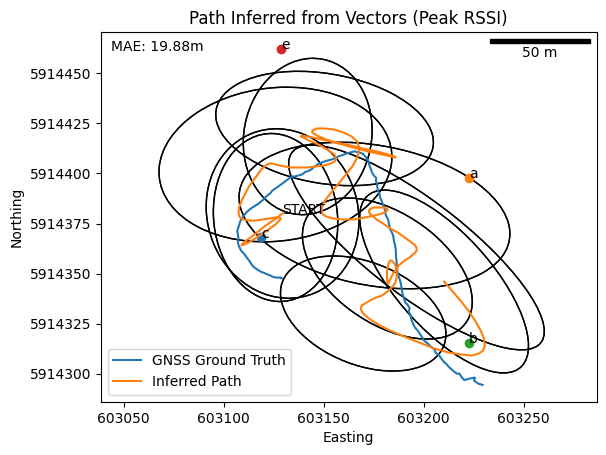

In [50]:
path.plot(startTime = startingTime+1, endTime = endingTime-2, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

plt.title("Path Inferred from Vectors (Peak RSSI)")